<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/LSTM_architecture_Demo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets

Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, SpatialDropout1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

#installing hugging face datasets
#numpy/pandas for data handling, matplotlib for plotting, Keras for building the neural network, sklearn for encoding labels and evaluating results.
#Added Bidirectional, SpatialDropout1D, EarlyStopping, ReduceLROnPlateau and class-weight utilities to fix the earlier accuracy/imbalance issues.


Loading the dataset

In [3]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

#Downloads the "emotion" dataset (short text sentences labeled with emotions) and converts it into pandas DataFrames

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Checking dataset

In [4]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

#Checks how many rows exist and how balanced the emotion classes are.

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Converting Labels to Emotional Name

In [5]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

#The dataset stores labels as numbers; this adds a readable emotion column.

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Label Encoding

In [6]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

#Converts emotion names back into numeric IDs the model can learn from (this re-encoding is a bit redundant since the numeric label column already existed, but it works fine).

Tokenization

In [7]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="<OOV>")

tokenizer.fit_on_texts(train_df["text"])

#Builds a vocabulary of the 10,000 most common words in the training text. Words outside this vocabulary become <OOV> (out of vocabulary).

Converting tokens to sequences

In [8]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
#Converts each sentence into a list of numbers (word IDs), since neural networks need numbers, not raw text.
X_test = tokenizer.texts_to_sequences(test_df["text"])

Padding

In [9]:
max_length = 40
#Makes every sentence the same length (40 tokens) by adding zeros at the end — needed because the model expects fixed-size input.

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Building the model

In [10]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length,
              mask_zero=True)
)

# SpatialDropout1D drops whole word-vectors instead of individual numbers -
# this regularizes the embedding layer much more effectively than plain Dropout for text.
model.add(SpatialDropout1D(0.3))

# Stacked Bidirectional LSTMs: reading the sentence forwards AND backwards
# helps the model pick up context words might come after the emotion cue too
# (e.g. "crying" after "feel like" needs the following words as well).
model.add(
    Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-5)))
)
model.add(Dropout(0.3))

model.add(
    Bidirectional(LSTM(64, kernel_regularizer=l2(1e-5)))
)
model.add(Dropout(0.4))

model.add(
    Dense(64, activation="relu", kernel_regularizer=l2(1e-5))
)
model.add(Dropout(0.3))

model.add(
    Dense(6, activation="softmax")
)

model.summary()

# Changes vs original architecture and why:
# - Embedding dim 64 -> 128: more capacity to represent word meaning.
# - mask_zero=True: LSTM now ignores the zero-padding instead of treating it as real input.
# - SpatialDropout1D(0.3) after the embedding: stronger, text-appropriate regularization.
# - Bidirectional(LSTM) x2 (128 then 64) instead of a single one-directional LSTM(64):
#   much better at capturing context in short emotional sentences.
# - Small L2 regularization on LSTM/Dense weights to reduce overfitting further.
# - Dropout tuned per-layer (0.3/0.3/0.4/0.3) rather than one large 0.5 dropout.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#Sets how the model learns: Adam optimizer, cross-entropy loss (standard for multi-class classification), tracking accuracy.


Training the model

Handling Class Imbalance


In [12]:
# The dataset is imbalanced (e.g. "joy" has 5362 training examples but
# "surprise" only has 572). This is exactly why "surprise" had only 0.12 recall
# and why short/ambiguous sentences like "I feel like crying" got dragged
# towards the majority classes. class_weight tells the model to pay more
# attention to mistakes on the rare classes during training.

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.2351397251814111), 1: np.float64(1.3766993632765445), 2: np.float64(0.49732686808404825), 3: np.float64(2.044989775051125), 4: np.float64(0.5715102157451064), 5: np.float64(4.662004662004662)}


In [13]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

#Trains for up to 25 passes over the data (instead of a fixed 8), but EarlyStopping
#will stop it automatically once validation accuracy stops improving for 4 epochs
#and restores the best-performing weights. ReduceLROnPlateau shrinks the learning
#rate when validation loss plateaus, helping the model fine-tune instead of
#overshooting. class_weight rebalances the loss so minority emotions (love, anger,
#surprise) aren't drowned out by the larger joy/sadness classes.


Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 338ms/step - accuracy: 0.2686 - loss: 1.5842 - val_accuracy: 0.5478 - val_loss: 1.1962 - learning_rate: 0.0010
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 341ms/step - accuracy: 0.8150 - loss: 0.5468 - val_accuracy: 0.8747 - val_loss: 0.4100 - learning_rate: 0.0010
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 65s 324ms/step - accuracy: 0.9196 - loss: 0.2541 - val_accuracy: 0.9013 - val_loss: 0.3409 - learning_rate: 0.0010
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 329ms/step - accuracy: 0.9460 - loss: 0.1782 - val_accuracy: 0.8831 - val_loss: 0.3623 - learning_rate: 0.0010
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 329ms/step - accuracy: 0.9590 - loss: 0.1307 - val_accuracy: 0.9019 - val_loss: 0.3495 - learning_rate: 0.0010
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 334ms/step - accuracy: 0.9723 - loss: 0.0932 - val_accuracy: 0.9059 - val_loss: 0.3490 - learning_rate: 5.0000e-04
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 85s 348ms/step - accuracy:

Accuracy Plot

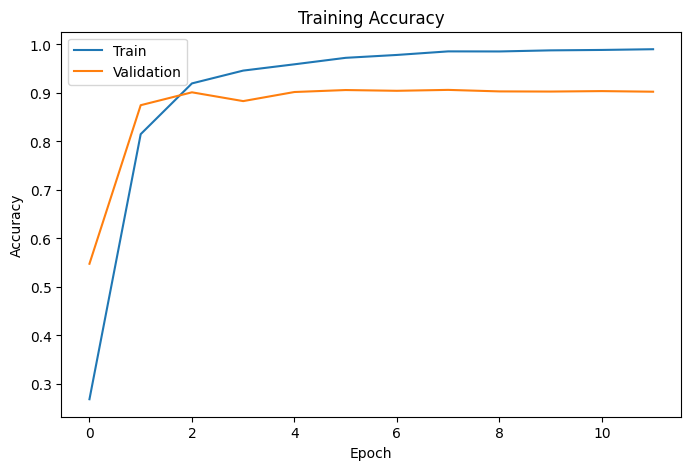

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

Loss Plot

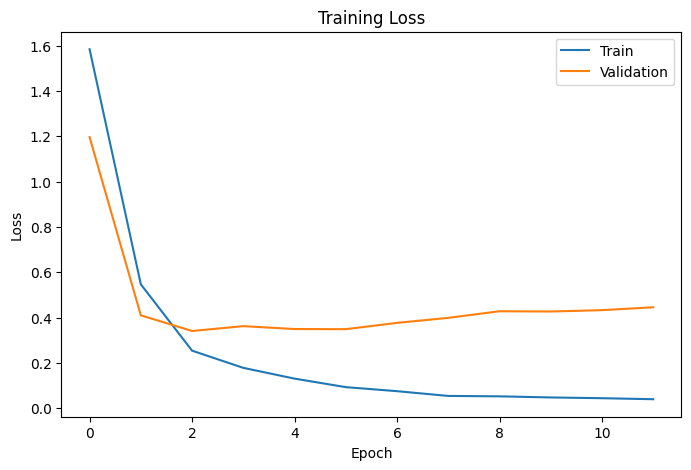

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Evaluation Of Model

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9000 - loss: 0.4062
Test Accuracy : 0.8999999761581421


Classification Model

In [17]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       275
           1       0.84      0.88      0.86       224
           2       0.94      0.91      0.92       695
           3       0.73      0.87      0.80       159
           4       0.96      0.93      0.94       581
           5       0.73      0.70      0.71        66

    accuracy                           0.90      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.90      0.90      0.90      2000



Confusion Matrix


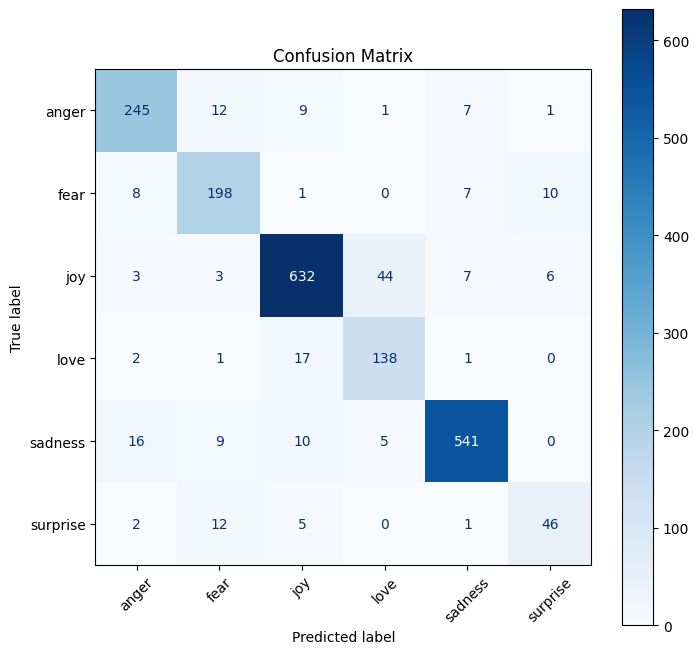

In [18]:
cm = confusion_matrix(y_test, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# This makes it easy to see exactly which emotions get confused with which -
# e.g. whether "sadness" sentences are being pulled towards "joy" or vice versa,
# which is the kind of mistake that produced the wrong "I feel like crying" -> "joy" prediction.


Predicting your own sentence

In [19]:
def predict_emotion(sentence, show_probabilities=True):
    """Predict the emotion of one or more raw sentences and optionally show
    the full probability distribution (useful for sanity-checking predictions
    that "look wrong" - often the correct class is a close second)."""
    if isinstance(sentence, str):
        sentence = [sentence]

    seq = tokenizer.texts_to_sequences(sentence)
    seq = pad_sequences(seq, maxlen=max_length, padding="post")

    probs = model.predict(seq, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    emotions = encoder.inverse_transform(pred_classes)

    for s, emo, p in zip(sentence, emotions, probs):
        print(f"Sentence: {s!r}")
        print(f"Predicted Emotion: {emo}")
        if show_probabilities:
            for cls, prob in sorted(zip(encoder.classes_, p), key=lambda x: -x[1]):
                print(f"    {cls:10s}: {prob:.3f}")
        print()

    return emotions

# A few test sentences, including the one that was misclassified before,
# plus some others to sanity check across different emotions.
test_sentences = [
    "I feel like crying",
    "I am so happy today, everything is going great",
    "I am furious that this happened again",
    "I am scared of what might happen next",
    "This is such a wonderful surprise, I did not expect this at all",
]

predict_emotion(test_sentences)


Sentence: 'I feel like crying'
Predicted Emotion: sadness
    sadness   : 0.459
    joy       : 0.343
    fear      : 0.139
    anger     : 0.039
    surprise  : 0.011
    love      : 0.009

Sentence: 'I am so happy today, everything is going great'
Predicted Emotion: joy
    joy       : 0.993
    sadness   : 0.003
    fear      : 0.003
    love      : 0.001
    anger     : 0.000
    surprise  : 0.000

Sentence: 'I am furious that this happened again'
Predicted Emotion: anger
    anger     : 0.998
    fear      : 0.001
    sadness   : 0.000
    joy       : 0.000
    surprise  : 0.000
    love      : 0.000

Sentence: 'I am scared of what might happen next'
Predicted Emotion: fear
    fear      : 0.994
    surprise  : 0.003
    anger     : 0.002
    joy       : 0.001
    sadness   : 0.001
    love      : 0.000

Sentence: 'This is such a wonderful surprise, I did not expect this at all'
Predicted Emotion: joy
    joy       : 0.999
    love      : 0.000
    fear      : 0.000
    anger     

array(['sadness', 'joy', 'anger', 'fear', 'joy'], dtype=object)